# Argument Mining
This takes in the 2 datasets of positive and negative comments and combines them into one and the runs argument mining on the to detect what typee of stance a comment is based on context and reasoning. This is then categorised in to support, oppose or neutral. This then produces a labelled dataset for each of the comments along with a model trained on the data. 

In [9]:
#load and combine datasets

import pandas as pd

positive_df = pd.read_csv("positive_comments_with_labels.csv")
negative_df = pd.read_csv("negative_comments_with_labels.csv")

df = pd.concat([positive_df, negative_df], ignore_index=True)

#makes comment column string, removes whitespace. Removes rows with empty comments and duplicate comments.
df["comment"] = df["comment"].astype(str).str.strip()
df = df.dropna(subset=["comment"]).drop_duplicates(subset=["comment"])

#adds the stance column
df["stance"] = ""

df.head(10)


,comment,sentiment,praise_label,praise_score,emotion,emotion_score,hate_label,hate_score,stance
0,Compare Doctor Mike and Sam Seder to Jordan Pe...,positive,neutral,0.845503,neutral,0.961623,NaN,NaN,
1,"""I would say that correlation does not equal c...",positive,negative,0.862059,disgust,0.734090,NaN,NaN,
2,There’s no absolute truth period Mike? Do y...,positive,negative,0.898172,surprise,0.642281,NaN,NaN,
3,the fact checks on the red haired girl where b...,positive,negative,0.913551,anger,0.910979,NaN,NaN,
4,It's fairly obvious that he means that what is...,positive,neutral,0.807305,neutral,0.954809,NaN,NaN,
5,Babies do not need a 70 vaccines schedule or m...,positive,negative,0.627259,neutral,0.905754,NaN,NaN,
6,Every point the doctor made others were like n...,positive,negative,0.714123,disgust,0.656152,NaN,NaN,
7,Did the girl said my friend got tumour and sav...,positive,neutral,0.767351,neutral,0.530886,NaN,NaN,
8,Thank you for the fact check. I dont think i w...,positive,positive,0.574036,surprise,0.496264,NaN,NaN,
9,This whole video feels like a political stunt....,positive,negative,0.885654,disgust,0.505468,NaN,NaN,


In [10]:
#assigns weak labels on keywords
def weak_label(comment):
    text = str(comment).lower()
    
    support_keywords = [
        "vaccines work",
        "get vaccinated",
        "safe and effective",
        "protects people",
        "trust science",
        "life saving",
        "proven to work",
        "important for public health",
        "prevents disease",
        "trust doctors"
    ]
    
    oppose_keywords = [
        "vaccines are dangerous",
        "side effects",
        "dont trust vaccines",
        "big pharma",
        "causes autism",
        "experimental",
        "not tested",
        "natural immunity",
        "vaccine injury",
        "vaccine deaths"
    ]
    
    for phrase in oppose_keywords:
        if phrase in text:
            return "oppose"
    
    for phrase in support_keywords:
        if phrase in text:
            return "support"
    
    return "neutral"

weak_labels = df["comment"].apply(weak_label)
df.head(10)

,comment,sentiment,praise_label,praise_score,emotion,emotion_score,hate_label,hate_score,stance
0,Compare Doctor Mike and Sam Seder to Jordan Pe...,positive,neutral,0.845503,neutral,0.961623,NaN,NaN,
1,"""I would say that correlation does not equal c...",positive,negative,0.862059,disgust,0.734090,NaN,NaN,
2,There’s no absolute truth period Mike? Do y...,positive,negative,0.898172,surprise,0.642281,NaN,NaN,
3,the fact checks on the red haired girl where b...,positive,negative,0.913551,anger,0.910979,NaN,NaN,
4,It's fairly obvious that he means that what is...,positive,neutral,0.807305,neutral,0.954809,NaN,NaN,
5,Babies do not need a 70 vaccines schedule or m...,positive,negative,0.627259,neutral,0.905754,NaN,NaN,
6,Every point the doctor made others were like n...,positive,negative,0.714123,disgust,0.656152,NaN,NaN,
7,Did the girl said my friend got tumour and sav...,positive,neutral,0.767351,neutral,0.530886,NaN,NaN,
8,Thank you for the fact check. I dont think i w...,positive,positive,0.574036,surprise,0.496264,NaN,NaN,
9,This whole video feels like a political stunt....,positive,negative,0.885654,disgust,0.505468,NaN,NaN,


In [11]:
import re

#looks for common reasoning patterns to try and identify a reason. 
def has_reason(comment):
    c = str(comment).lower()
    patterns = [
        r"\bbecause\b", r"\bsince\b", r"\btherefore\b", r"\bas a result\b",
        r"\bdue to\b", r"\bbecause of\b", r"\bfor the reason\b", r"\bso\b"
    ]
    return any(re.search(p, c) for p in patterns)


df["has_reason"] = df["comment"].apply(has_reason)

df.head(10)

,comment,sentiment,praise_label,praise_score,emotion,emotion_score,hate_label,hate_score,stance,has_reason
0,Compare Doctor Mike and Sam Seder to Jordan Pe...,positive,neutral,0.845503,neutral,0.961623,NaN,NaN,,False
1,"""I would say that correlation does not equal c...",positive,negative,0.862059,disgust,0.734090,NaN,NaN,,False
2,There’s no absolute truth period Mike? Do y...,positive,negative,0.898172,surprise,0.642281,NaN,NaN,,False
3,the fact checks on the red haired girl where b...,positive,negative,0.913551,anger,0.910979,NaN,NaN,,False
4,It's fairly obvious that he means that what is...,positive,neutral,0.807305,neutral,0.954809,NaN,NaN,,False
5,Babies do not need a 70 vaccines schedule or m...,positive,negative,0.627259,neutral,0.905754,NaN,NaN,,False
6,Every point the doctor made others were like n...,positive,negative,0.714123,disgust,0.656152,NaN,NaN,,False
7,Did the girl said my friend got tumour and sav...,positive,neutral,0.767351,neutral,0.530886,NaN,NaN,,False
8,Thank you for the fact check. I dont think i w...,positive,positive,0.574036,surprise,0.496264,NaN,NaN,,False
9,This whole video feels like a political stunt....,positive,negative,0.885654,disgust,0.505468,NaN,NaN,,False


In [12]:
# needed to check if GPU is available for training, I used 3070 Ti with torch and CUDA. 
# Took around 45 mins for stance detection with this
import sys
print(sys.executable)

import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

c:\Users\Leo H\AppData\Local\Programs\Python\Python313\python.exe
torch: 2.12.0+cpu
CUDA available: False
GPU count: 0


# Detects the stance
I accidently ran this again on my laptop. Im not running it again on my PC
It just gave a head with columns with a label about what the stance is. 
For the table go to "youtube_comments_argument_mined.csv"

In [13]:
#stance detection
import torch
from transformers import pipeline
from tqdm import tqdm

#uses GPU if available
device = 0 if torch.cuda.is_available() else -1
zs = pipeline("zero-shot-classification", device=device)
print("pipeline:", zs.model.device)

#candidate labels for stance detection
candidate_labels = ["supports the vaccine", "opposes the vaccine", "neutral"]

#gets the stances of the comments in batches. may need tuning depending on machine power
def get_stances(comments, batch_size=128, show_progress=True):
    stances = []
    iterator = range(0, len(comments), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Processing comments")
    for i in iterator:
        batch = comments[i:i+batch_size]
        results = zs(batch, candidate_labels)
        for r in results:
            top = r["labels"][0]
            if "supports" in top:
                stances.append("support")
            elif "opposes" in top:
                stances.append("oppose")
            else:
                stances.append("neutral")
    return stances

#fills the stance column with the predicted stances from the zero-shot classifier
df["stance"] = get_stances(df["comment"].tolist())

df.head(10)

KeyboardInterrupt: 

In [ ]:
#had to add this in afterwards to get the argument mined dataset without predictions
df_clean = df.drop("predicted_stance", axis=1, errors="ignore")
df_clean.to_csv("youtube_comments_argument_mined.csv", index=False)

# Training
Uses the GPU is available however it didnt seem to work, wasnt really needed as didnt take too long to run. 
Trains the model on the dataset with stance detection and arugment mining. Uses both logisitic regression and randomised search to get prediction. 
Saves the best model

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
from scipy.stats import loguniform

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

device = 0 if torch.cuda.is_available() else -1
if 'zs' not in globals():
    from transformers import pipeline
    zs = pipeline("zero-shot-classification", device=device)


train_df = df[df["stance"].isin(["support", "oppose", "neutral"])].reset_index(drop=True)
x = train_df["comment"]
y = train_df["stance"]


X_train, X_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"))
])

param_distributions = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [2, 5, 10],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__max_features": [10000, 20000, None],
    "clf__C": loguniform(0.1, 10),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(pipe, param_distributions=param_distributions,
                        n_iter=10,scoring="accuracy", cv=cv, n_jobs=-1, verbose=2)
search.fit(x, y)

print("\nBest CV accuracy:", search.best_score_)
print("\nBest params:", search.best_params_)
print("\nTest set accuracy:", search.best_estimator_.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, search.best_estimator_.predict(X_test)))

best_model = search.best_estimator_
best_score = search.best_score_

joblib.dump(best_model, "best_stance_model.joblib")
df["predicted_stance"] = best_model.predict(df["comment"])
df.to_csv("youtube_comments_with_predictions.csv", index=False)


[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 3871.44it/s]


Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV accuracy: 0.8269381200639322

Best params: {'clf__C': np.float64(5.666792862408619), 'tfidf__max_df': 0.9, 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Test set accuracy: 0.9857664693286308

Classification Report:
              precision    recall  f1-score   support

     neutral       1.00      0.98      0.99      5491
      oppose       0.97      0.99      0.98      1905
     support       0.94      1.00      0.97       543

    accuracy                           0.99      7939
   macro avg       0.97      0.99      0.98      7939
weighted avg       0.99      0.99      0.99      7939



# Visualisation
This graph shows the stances each comment makes VS the predicted stance. As it can be found the overwhelming majority supports vaccinations even when its not explicitly mentioned the context of the comment can find it. 

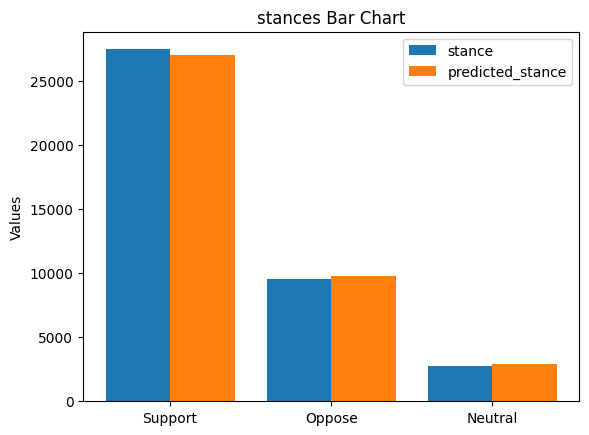

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stance_counts = df['stance'].value_counts()
predicted_stance_counts = df['predicted_stance'].value_counts()


categories = ['Support', 'Oppose', 'Neutral']

w, x = 0.4, np.arange(len(categories))

fig, ax = plt.subplots()
ax.bar(x - w/2, stance_counts, width=w, label='stance')
ax.bar(x + w/2, predicted_stance_counts, width=w, label='predicted_stance')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Values')
ax.set_title('stances Bar Chart')
ax.legend()

plt.show()